# 02 — Graph Analytics: Customer-Merchant Affinity
**Merchant Network Analytics — Capstone Project BNI ODP**

---

## Konsep: Merchant Affinity dari Perilaku Pelanggan

Graph yang dibangun bukan dari transaksi langsung antar-merchant,
melainkan dari **kesamaan pelanggan** (customer overlap).

**Logika:**
- Customer C1 bertransaksi di M1 dan M2
- Customer C2 bertransaksi di M1 dan M2
- → M1 dan M2 memiliki 2 shared customers → terbentuk edge

**Struktur Graph:**
- **Node** = Merchant (M-codes)
- **Edge** = ada jika shared customers ≥ threshold
- **Weight** = Jaccard similarity (menormalisasi bias merchant besar)
- **Undirected** = affinitas tidak punya arah

**Mengapa Jaccard, bukan raw count?**
Raw count bias ke merchant besar. Merchant dengan 5000 customer
otomatis share banyak customer dengan semua merchant lain — bukan karena
ada relasi strategis. Jaccard = |A∩B| / |A∪B| menormalisasi ini.

**Input:** transactions_clean.csv, merchants_clean.csv, profiles_clean.csv
**Output:** affinity_edge_table.csv, feature_table.csv, graph_object.pkl

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

import os
PROJECT_ROOT = '.' if os.path.isdir('./data') else '..'

# Load data
trx_clean     = pd.read_csv(f'{PROJECT_ROOT}/data/processed/transactions_clean.csv')
merchants_clean = pd.read_csv(f'{PROJECT_ROOT}/data/processed/merchants_clean.csv')
profile_clean = pd.read_csv(f'{PROJECT_ROOT}/data/processed/profiles_clean.csv')

print(f"Transactions clean : {len(trx_clean):,} rows")
print(f"Merchants          : {len(merchants_clean)} merchants")
print(f"Profiles           : {len(profile_clean)} profiles")

Transactions clean : 64,125 rows
Merchants          : 656 merchants
Profiles           : 708 profiles


## 1. Ekstrak Transaksi C2M

Filter hanya transaksi Customer→Merchant (source_id diawali 'C').
Ini yang menjadi dasar perhitungan customer overlap antar-merchant.

In [2]:
# Filter C2M transactions
# 'trx_type' kolom sudah ada dari notebook 01
if 'trx_type' in trx_clean.columns:
    c2m = trx_clean[trx_clean['trx_type'] == 'C2M'][['source_id', 'target_id']].copy()
else:
    c2m = trx_clean[trx_clean['source_id'].str.startswith('C')][['source_id', 'target_id']].copy()

# Rename untuk clarity
c2m.columns = ['customer_id', 'merchant_id']

# Pastikan merchant valid
valid_merchants = set(merchants_clean['merchant_id'].tolist())
c2m = c2m[c2m['merchant_id'].isin(valid_merchants)]

# Drop duplikat: satu customer hanya dihitung sekali per merchant
c2m_unique = c2m.drop_duplicates()

print(f"Total C2M transactions         : {len(trx_clean[trx_clean['source_id'].str.startswith('C')]):,}")
print(f"Unique customer-merchant pairs : {len(c2m_unique):,}")
print(f"Unique customers               : {c2m_unique['customer_id'].nunique():,}")
print(f"Unique merchants (dalam C2M)   : {c2m_unique['merchant_id'].nunique()}")

# Statistik customer per merchant
cust_per_merchant = c2m_unique.groupby('merchant_id')['customer_id'].count()
print(f"\nCustomer per merchant:")
print(f"  Min    : {cust_per_merchant.min()}")
print(f"  Median : {cust_per_merchant.median():.0f}")
print(f"  Mean   : {cust_per_merchant.mean():.1f}")
print(f"  Max    : {cust_per_merchant.max()}")

Total C2M transactions         : 45,071
Unique customer-merchant pairs : 41,068
Unique customers               : 2,000
Unique merchants (dalam C2M)   : 656

Customer per merchant:
  Min    : 20
  Median : 53
  Mean   : 62.6
  Max    : 391


## 2. Bangun Customer-Merchant Index

Untuk efisiensi, gunakan inverted index: customer → set of merchants.
Lalu hitung co-occurrence (shared customers) antar pasangan merchant
tanpa harus iterasi semua kombinasi pasangan merchant secara langsung.

Kompleksitas: O(customers × avg_merchants_per_customer²)
jauh lebih efisien dari O(merchants²).

In [3]:
# Bangun index: merchant → set of customers
merchant_customers = (
    c2m_unique.groupby('merchant_id')['customer_id']
    .apply(set)
    .to_dict()
)

# Bangun inverted index: customer → set of merchants
customer_to_merchants = (
    c2m_unique.groupby('customer_id')['merchant_id']
    .apply(set)
    .to_dict()
)

# Hitung co-occurrence via inverted index (efisien)
print("Menghitung customer overlap antar merchant...")
cooccurrence = defaultdict(int)
for cust_id, merchant_set in customer_to_merchants.items():
    merchant_list = sorted(list(merchant_set))  # sort untuk consistent ordering
    for m1, m2 in combinations(merchant_list, 2):
        cooccurrence[(m1, m2)] += 1

print(f"Jumlah pasangan dengan minimal 1 shared customer: {len(cooccurrence):,}")

# Preview distribusi shared customer count
shared_counts = list(cooccurrence.values())
print(f"\nDistribusi shared customer count:")
for threshold in [1, 2, 3, 5, 10]:
    count = sum(1 for v in shared_counts if v >= threshold)
    print(f"  Pasangan dengan shared_customers >= {threshold:2d}: {count:,}")

Menghitung customer overlap antar merchant...
Jumlah pasangan dengan minimal 1 shared customer: 167,322

Distribusi shared customer count:
  Pasangan dengan shared_customers >=  1: 167,322
  Pasangan dengan shared_customers >=  2: 102,674
  Pasangan dengan shared_customers >=  3: 54,997
  Pasangan dengan shared_customers >=  5: 17,377
  Pasangan dengan shared_customers >= 10: 3,821


## 3. Hitung Jaccard Similarity & Terapkan Threshold

**Jaccard Similarity** = |A ∩ B| / |A ∪ B|
- Range: 0 (tidak ada overlap) → 1 (customer identik)
- Normalisasi: merchant besar dengan 5000 customer tidak secara otomatis 
  punya Jaccard tinggi dengan semua merchant

**Threshold yang digunakan:**
- `shared_customers >= 3` — minimal 3 customer bersama (bukan kebetulan)
- `jaccard >= 0.05` — minimal 5% overlap dari gabungan customer base

**Justifikasi threshold:**
Dua kondisi diperlukan untuk menghindari dua jenis noise:
1. Raw count >= 3 → menghindari edge dari 1-2 shared customer yang bisa kebetulan
2. Jaccard >= 0.05 → menghindari merchant besar yang share sedikit % customer

In [4]:
# Threshold
MIN_SHARED_CUSTOMERS = 3
MIN_JACCARD = 0.05

print(f"Menghitung Jaccard similarity...")
print(f"Threshold: shared >= {MIN_SHARED_CUSTOMERS} AND jaccard >= {MIN_JACCARD}")

edges = []
for (m1, m2), shared_count in cooccurrence.items():
    if shared_count < MIN_SHARED_CUSTOMERS:
        continue
    
    # Jaccard = intersection / union
    set1 = merchant_customers.get(m1, set())
    set2 = merchant_customers.get(m2, set())
    union_count = len(set1 | set2)
    
    if union_count == 0:
        continue
    
    jaccard = shared_count / union_count
    
    if jaccard < MIN_JACCARD:
        continue
    
    edges.append({
        'source'          : m1,
        'target'          : m2,
        'shared_customers': shared_count,
        'jaccard'         : round(jaccard, 6),
        'size_m1'         : len(set1),
        'size_m2'         : len(set2),
    })

affinity_edge_table = pd.DataFrame(edges)
affinity_edge_table = affinity_edge_table.sort_values('jaccard', ascending=False).reset_index(drop=True)

print(f"\n=== Affinity Edge Table ===")
print(f"Jumlah edges (relasi affinitas): {len(affinity_edge_table):,}")
print(f"Jumlah merchant terlibat       : {len(set(affinity_edge_table['source']) | set(affinity_edge_table['target']))}")
print(f"\nDistribusi Jaccard:")
print(affinity_edge_table['jaccard'].describe().round(4))
print(f"\nDistribusi shared_customers:")
print(affinity_edge_table['shared_customers'].describe().round(1))
print(f"\nTop 10 pasangan (by Jaccard):")
print(affinity_edge_table.head(10)[['source', 'target', 'shared_customers', 'jaccard']].to_string())

Menghitung Jaccard similarity...
Threshold: shared >= 3 AND jaccard >= 0.05

=== Affinity Edge Table ===
Jumlah edges (relasi affinitas): 1,429
Jumlah merchant terlibat       : 632

Distribusi Jaccard:
count    1429.0000
mean        0.0582
std         0.0098
min         0.0500
25%         0.0517
50%         0.0550
75%         0.0610
max         0.1327
Name: jaccard, dtype: float64

Distribusi shared_customers:
count    1429.0
mean       11.7
std        12.3
min         3.0
25%         5.0
50%         6.0
75%         9.0
max        90.0
Name: shared_customers, dtype: float64

Top 10 pasangan (by Jaccard):
  source target  shared_customers   jaccard
0  M0227  M0248                90  0.132743
1  M0242  M0528                67  0.118584
2  M0242  M0248                78  0.118182
3  M0248  M0700                72  0.111455
4  M0248  M0528                62  0.105802
5  M0053  M0248                63  0.104651
6  M0274  M0378                52  0.102564
7  M0205  M0376                49  0

## 4. Bangun Graph

Graph ini **undirected** karena affinitas pelanggan tidak punya arah —
jika M1 dan M2 berbagi pelanggan, relasi itu simetris.

Berbeda dengan M2M transaction graph (directed), affinity graph
tidak memiliki in-degree / out-degree. Metrik yang relevan:
- **Degree** — jumlah merchant lain yang punya customer overlap bermakna
- **Weighted Degree** — total Jaccard weight dari semua tetangga
- **PageRank** — merchant yang terhubung ke banyak merchant "penting"
- **Betweenness** — merchant yang menjadi jembatan antar cluster ekosistem
- **Community** — cluster merchant dengan basis pelanggan yang serupa

In [5]:
# Bangun undirected graph dengan Jaccard sebagai weight
G = nx.from_pandas_edgelist(
    affinity_edge_table,
    source='source',
    target='target',
    edge_attr=['shared_customers', 'jaccard'],
    create_using=nx.Graph()  # UNDIRECTED
)

print(f"=== Graph Summary ===")
print(f"Nodes (merchants)   : {G.number_of_nodes()}")
print(f"Edges (affinitas)   : {G.number_of_edges()}")
print(f"Density             : {nx.density(G):.4f}")
print(f"Is connected        : {nx.is_connected(G)}")

components = list(nx.connected_components(G))
print(f"Jumlah komponen     : {len(components)}")
print(f"Komponen terbesar   : {len(max(components, key=len))} nodes")

# --- Hitung semua metrik graph ---

# Degree (jumlah koneksi affinitas per merchant)
degree_dict = dict(G.degree())

# Weighted degree (sum of Jaccard weights)
weighted_degree = {}
for node in G.nodes():
    weighted_degree[node] = sum(
        d.get('jaccard', 0) for _, _, d in G.edges(node, data=True)
    )

# PageRank (weighted by Jaccard)
pagerank = nx.pagerank(G, weight='jaccard', alpha=0.85)

# Betweenness centrality
print("Menghitung betweenness centrality (mungkin butuh beberapa detik)...")
betweenness = nx.betweenness_centrality(G, weight='jaccard', normalized=True)

# Community detection (Louvain, undirected)
from networkx.algorithms.community import louvain_communities
communities = louvain_communities(G, weight='jaccard', seed=42)

community_map = {}
for i, community in enumerate(communities):
    for node in community:
        community_map[node] = i

print(f"\n=== Metrik Graph Computed ===")
print(f"Communities detected : {len(communities)}")
print(f"Community sizes      : {sorted([len(c) for c in communities], reverse=True)[:10]}")

=== Graph Summary ===
Nodes (merchants)   : 632
Edges (affinitas)   : 1429
Density             : 0.0072
Is connected        : False
Jumlah komponen     : 2
Komponen terbesar   : 630 nodes
Menghitung betweenness centrality (mungkin butuh beberapa detik)...

=== Metrik Graph Computed ===
Communities detected : 17
Community sizes      : [67, 62, 53, 48, 46, 40, 39, 38, 36, 31]


## 5. Tambah Connected BNI Ratio

Metrik kunci untuk akuisisi: berapa persen tetangga (merchant dengan
customer overlap) yang sudah nasabah BNI.

Interpretasi bisnis: merchant dengan connected_bni_ratio tinggi
berarti basis pelanggannya sudah banyak yang juga berbelanja di merchant
BNI lain. Mengakuisisi merchant ini = memperluas jangkauan ke pelanggan
yang sudah ada di ekosistem BNI.

In [6]:
# Set merchant BNI untuk hitung connected_bni_ratio
bni_set = set(merchants_clean[merchants_clean['is_nasabah_bni'] == 'Ya']['merchant_id'])

# Hitung connected_bni_ratio per node
connected_bni_ratio = {}
for node in G.nodes():
    neighbors = set(G.neighbors(node))
    if len(neighbors) == 0:
        connected_bni_ratio[node] = 0.0
    else:
        connected_bni_ratio[node] = len(neighbors & bni_set) / len(neighbors)

# Avg Jaccard dengan tetangga (kualitas affinitas rata-rata)
avg_neighbor_jaccard = {}
for node in G.nodes():
    edges_data = [d.get('jaccard', 0) for _, _, d in G.edges(node, data=True)]
    avg_neighbor_jaccard[node] = np.mean(edges_data) if edges_data else 0.0

# Ukuran community
community_sizes = {}
for i, community in enumerate(communities):
    for node in community:
        community_sizes[node] = len(community)

# Kompilasi ke DataFrame
graph_features = pd.DataFrame({
    'merchant_id'          : list(G.nodes()),
    'degree'               : [degree_dict.get(n, 0) for n in G.nodes()],
    'weighted_degree'      : [weighted_degree.get(n, 0.0) for n in G.nodes()],
    'pagerank'             : [pagerank.get(n, 0.0) for n in G.nodes()],
    'betweenness'          : [betweenness.get(n, 0.0) for n in G.nodes()],
    'community_id'         : [community_map.get(n, -1) for n in G.nodes()],
    'community_size'       : [community_sizes.get(n, 1) for n in G.nodes()],
    'connected_bni_ratio'  : [connected_bni_ratio.get(n, 0.0) for n in G.nodes()],
    'avg_neighbor_jaccard' : [avg_neighbor_jaccard.get(n, 0.0) for n in G.nodes()],
})

# Tambah jumlah customer per merchant (dari C2M data)
cust_per_merchant_df = c2m_unique.groupby('merchant_id')['customer_id'].count().reset_index()
cust_per_merchant_df.columns = ['merchant_id', 'n_customers']
graph_features = graph_features.merge(cust_per_merchant_df, on='merchant_id', how='left')
graph_features['n_customers'] = graph_features['n_customers'].fillna(0).astype(int)

print(f"=== Graph Features ===")
print(f"Shape: {graph_features.shape}")
print(graph_features.describe().round(4))

=== Graph Features ===
Shape: (632, 10)
         degree  weighted_degree  pagerank  betweenness  community_id  \
count  632.0000         632.0000  632.0000     632.0000       632.000   
mean     4.5222           0.2632    0.0016       0.0060         8.288   
std      4.2909           0.2958    0.0009       0.0069         4.669   
min      1.0000           0.0500    0.0004       0.0000         0.000   
25%      2.0000           0.1168    0.0010       0.0012         5.000   
50%      3.0000           0.1903    0.0014       0.0038         9.000   
75%      5.0000           0.2896    0.0019       0.0079        12.000   
max     30.0000           2.2706    0.0070       0.0467        16.000   

       community_size  connected_bni_ratio  avg_neighbor_jaccard  n_customers  
count        632.0000             632.0000              632.0000     632.0000  
mean          43.1329               0.6752                0.0562      63.2310  
std           13.5410               0.2854                0.00

In [7]:
top_pr = graph_features.nlargest(10, 'pagerank').merge(
    merchants_clean[['merchant_id', 'nama', 'kategori', 'is_nasabah_bni', 'kota']],
    on='merchant_id'
)
print("=== Top 10 Merchants by PageRank (Affinity Graph) ===")
print(top_pr[['merchant_id', 'nama', 'kategori', 'is_nasabah_bni',
              'pagerank', 'degree', 'connected_bni_ratio', 'n_customers']].to_string())

=== Top 10 Merchants by PageRank (Affinity Graph) ===
  merchant_id                   nama     kategori is_nasabah_bni  pagerank  degree  connected_bni_ratio  n_customers
0       M0227        UD Kain Harmoni      Fashion             Ya  0.007023      30             0.800000          391
1       M0248     PT Tekstil Pratama      Fashion          Tidak  0.006426      27             0.703704          377
2       M0242   PT Tekstil Bang Jali      Fashion             Ya  0.005978      25             0.760000          361
3       M0528    PT Elektronik Buana  Electronics             Ya  0.005929      26             0.653846          271
4       M0124      UD Supplier Utama          F&B             Ya  0.005874      29             0.724138          252
5       M0700    CV Sparepart Sukses   Automotive             Ya  0.005566      26             0.692308          341
6       M0157    UD Supplier Harmoni          F&B             Ya  0.005473      26             0.769231          280
7       M0

## 6. Visualisasi

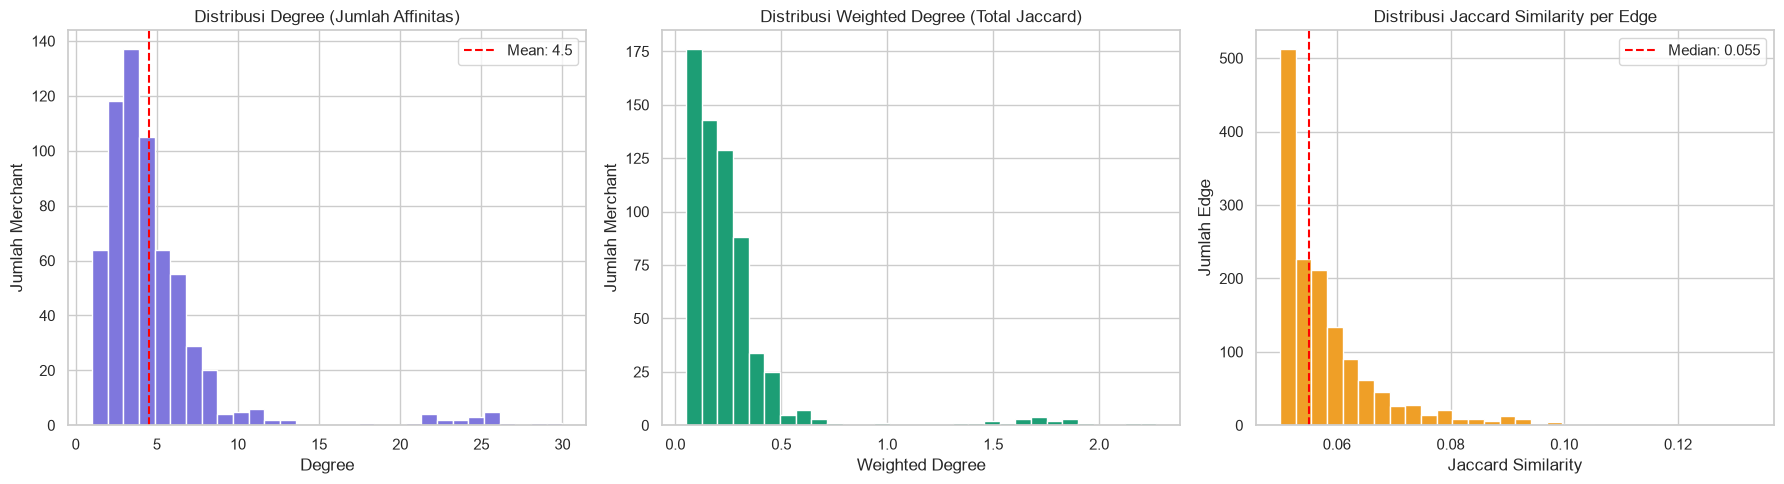

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Degree distribution
degrees = list(degree_dict.values())
axes[0].hist(degrees, bins=30, color='#7F77DD', edgecolor='white')
axes[0].set_title('Distribusi Degree (Jumlah Affinitas)')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Jumlah Merchant')
axes[0].axvline(np.mean(degrees), color='red', linestyle='--',
                label=f'Mean: {np.mean(degrees):.1f}')
axes[0].legend()

# Weighted degree distribution
wd_values = list(weighted_degree.values())
axes[1].hist(wd_values, bins=30, color='#1D9E75', edgecolor='white')
axes[1].set_title('Distribusi Weighted Degree (Total Jaccard)')
axes[1].set_xlabel('Weighted Degree')
axes[1].set_ylabel('Jumlah Merchant')

# Jaccard distribution per edge
axes[2].hist(affinity_edge_table['jaccard'], bins=30, color='#EF9F27', edgecolor='white')
axes[2].set_title('Distribusi Jaccard Similarity per Edge')
axes[2].set_xlabel('Jaccard Similarity')
axes[2].set_ylabel('Jumlah Edge')
axes[2].axvline(affinity_edge_table['jaccard'].median(), color='red', linestyle='--',
                label=f"Median: {affinity_edge_table['jaccard'].median():.3f}")
axes[2].legend()

plt.tight_layout()
import os
os.makedirs(f'{PROJECT_ROOT}/notebooks/plots', exist_ok=True)
plt.savefig(f'{PROJECT_ROOT}/notebooks/plots/08_affinity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

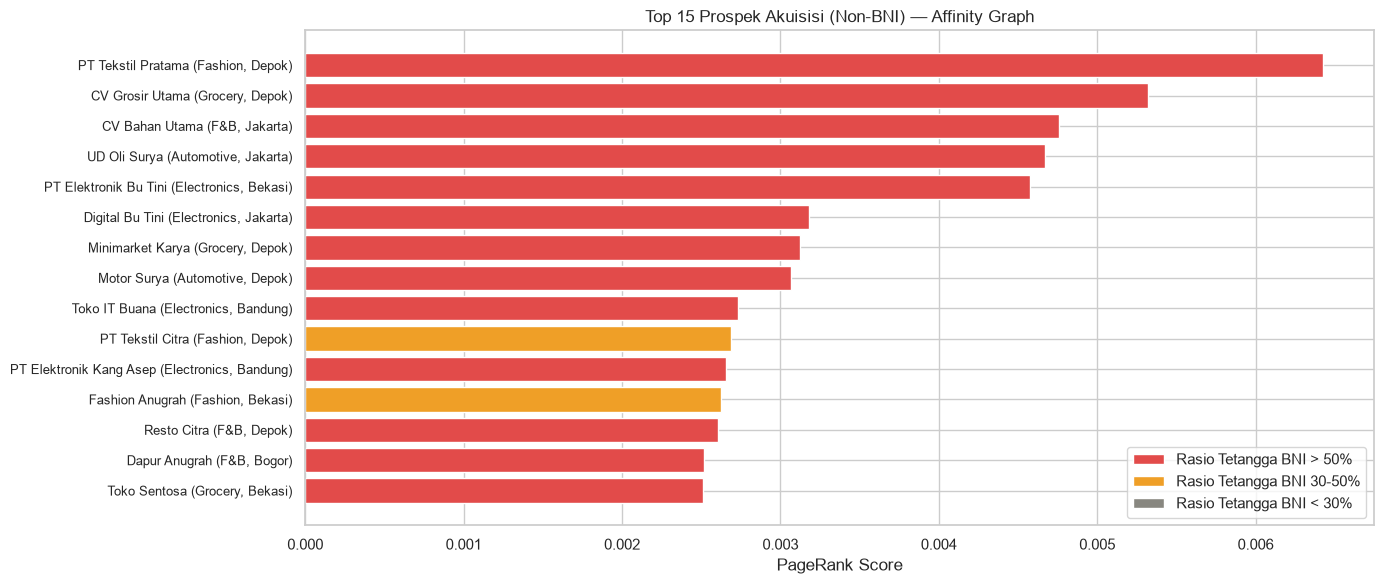

In [9]:
non_bni_features = graph_features.merge(
    merchants_clean[['merchant_id', 'nama', 'kategori', 'is_nasabah_bni', 'kota']],
    on='merchant_id'
)
non_bni_top = non_bni_features[non_bni_features['is_nasabah_bni'] == 'Tidak'].nlargest(15, 'pagerank')

fig, ax = plt.subplots(figsize=(14, 6))
colors_bar = ['#E24B4A' if r > 0.5 else '#EF9F27' if r > 0.3 else '#888780'
              for r in non_bni_top['connected_bni_ratio']]
ax.barh(range(len(non_bni_top)), non_bni_top['pagerank'], color=colors_bar)
ax.set_yticks(range(len(non_bni_top)))
ax.set_yticklabels([f"{row['nama'][:35]} ({row['kategori']}, {row['kota']})"
                    for _, row in non_bni_top.iterrows()], fontsize=9)
ax.set_xlabel('PageRank Score')
ax.set_title('Top 15 Prospek Akuisisi (Non-BNI) — Affinity Graph')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='Rasio Tetangga BNI > 50%'),
    Patch(facecolor='#EF9F27', label='Rasio Tetangga BNI 30-50%'),
    Patch(facecolor='#888780', label='Rasio Tetangga BNI < 30%'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/notebooks/plots/09_affinity_top_targets.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
community_analysis = non_bni_features.groupby('community_id').agg(
    size=('merchant_id', 'count'),
    n_bni=('is_nasabah_bni', lambda x: (x == 'Ya').sum()),
    n_non_bni=('is_nasabah_bni', lambda x: (x == 'Tidak').sum()),
    avg_pagerank=('pagerank', 'mean'),
    avg_jaccard=('avg_neighbor_jaccard', 'mean'),
    dominant_category=('kategori', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Mixed'),
    dominant_city=('kota', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Mixed'),
).reset_index()

community_analysis['bni_penetration_pct'] = (
    community_analysis['n_bni'] / community_analysis['size'] * 100
).round(1)

community_analysis['label'] = community_analysis.apply(
    lambda r: f"{r['dominant_category']} {r['dominant_city']} ({int(r['size'])} merchant)", axis=1
)

community_analysis = community_analysis[community_analysis['size'] >= 3].sort_values('n_non_bni', ascending=False)
print("=== Analisis Ekosistem (Community) ===")
print(community_analysis.head(10).to_string())

=== Analisis Ekosistem (Community) ===
    community_id  size  n_bni  n_non_bni  avg_pagerank  avg_jaccard dominant_category dominant_city  bni_penetration_pct                            label
9              9    62     37         25      0.001488     0.055908               F&B     Tangerang                 59.7      F&B Tangerang (62 merchant)
12            12    67     43         24      0.001464     0.055528           Fashion       Jakarta                 64.2    Fashion Jakarta (67 merchant)
8              8    53     34         19      0.001447     0.056398               F&B       Bandung                 64.2        F&B Bandung (53 merchant)
14            14    48     32         16      0.001462     0.056076               F&B         Depok                 66.7          F&B Depok (48 merchant)
16            16    46     30         16      0.003392     0.061843               F&B     Tangerang                 65.2      F&B Tangerang (46 merchant)
7              7    40     26        

In [11]:
from pyvis.network import Network

top_nodes = graph_features.nlargest(80, 'degree')['merchant_id'].tolist()
top_nodes = [n for n in top_nodes if n in G.nodes()]
G_sub = G.subgraph(top_nodes).copy()

# Compute layout
import networkx as nx
pos = nx.spring_layout(G_sub, k=2, seed=42, weight='jaccard')

net = Network(height='700px', width='100%', bgcolor='#ffffff',
              font_color='#333333', directed=False, notebook=True, cdn_resources='remote')

# Normalize pagerank untuk ukuran node
pr_values = {n: pagerank.get(n, 0) for n in G_sub.nodes()}
pr_min = min(pr_values.values())
pr_max = max(pr_values.values())

for node in G_sub.nodes():
    m_info = merchants_clean[merchants_clean['merchant_id'] == node]
    if len(m_info) == 0:
        continue
    m = m_info.iloc[0]
    gf = graph_features[graph_features['merchant_id'] == node]
    g = gf.iloc[0] if len(gf) > 0 else None

    is_bni = m['is_nasabah_bni'] == 'Ya'
    color = '#1D9E75' if is_bni else '#E24B4A'

    # Normalize size
    pr_val = pr_values.get(node, pr_min)
    size = 10 + (pr_val - pr_min) / (pr_max - pr_min + 1e-10) * 40

    title = (f"<b>{m['nama']}</b><br>"
             f"ID: {node}<br>Kategori: {m['kategori']}<br>"
             f"Kota: {m['kota']}<br>Status BNI: {m['is_nasabah_bni']}<br>"
             f"PageRank: {pr_val:.4f}<br>"
             f"Degree: {degree_dict.get(node, 0)}<br>"
             f"Affinitas Mitra BNI: {connected_bni_ratio.get(node, 0):.0%}")

    net.add_node(node, label=str(m['nama'])[:15] if pd.notna(m['nama']) else node,
                 title=title, size=size, color=color, shape='dot')

for u, v, data in G_sub.edges(data=True):
    jaccard_val = data.get('jaccard', 0.05)
    shared_val = data.get('shared_customers', 0)
    net.add_edge(u, v, value=jaccard_val * 10,
                 title=f"Shared customers: {shared_val}<br>Jaccard: {jaccard_val:.3f}")

net.set_options("""
{
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -50,
      "centralGravity": 0.005,
      "springLength": 150,
      "springConstant": 0.08
    },
    "solver": "forceAtlas2Based",
    "stabilization": {"iterations": 150}
  }
}
""")

net.save_graph(f'{PROJECT_ROOT}/notebooks/plots/network_affinity_graph.html')
print("Network affinity graph saved: notebooks/plots/network_affinity_graph.html")
print("Hijau = Nasabah BNI | Merah = Belum BNI | Ukuran = PageRank")

Network affinity graph saved: notebooks/plots/network_affinity_graph.html
Hijau = Nasabah BNI | Merah = Belum BNI | Ukuran = PageRank


## 7. Konstruksi Feature Table untuk ML

Feature table menggabungkan:
- Merchant attributes (dari merchants_clean)
- Graph metrics dari affinity graph (notebook ini)
- Profile data (dari profiles_clean)

### Catatan Leakage Prevention (untuk Notebook 03)

Target variable di notebook 03 akan dikonstruksi dari:
`pagerank`, `connected_bni_ratio`, `degree`, `weighted_degree`

Fitur-fitur ini TIDAK BOLEH masuk ke training features di notebook 03.
Kolom tetap ada di feature_table.csv, tapi akan dieksklusi di notebook 03.

In [12]:
# Mulai dari merchants_clean (semua merchant)
feature_table = merchants_clean.copy()

# Merge graph features
feature_table = feature_table.merge(graph_features, on='merchant_id', how='left')

# Merge profile
feature_table = feature_table.merge(profile_clean, on='merchant_id', how='left')

# Fill NULL untuk merchant yang tidak ada di graph
graph_fill_cols = ['degree', 'weighted_degree', 'pagerank', 'betweenness',
                   'community_size', 'connected_bni_ratio', 'avg_neighbor_jaccard', 'n_customers']
for col in graph_fill_cols:
    feature_table[col] = feature_table[col].fillna(0)
feature_table['community_id'] = feature_table['community_id'].fillna(-1).astype(int)

# Fitur turunan
# is_hub: degree di atas median + 1 std
degree_threshold = feature_table['degree'].median() + feature_table['degree'].std()
feature_table['is_hub'] = (feature_table['degree'] > degree_threshold).astype(int)

# customer_density: pelanggan per satuan affinitas (proxy efisiensi ekosistem)
feature_table['customer_density'] = (
    feature_table['n_customers'] / (feature_table['degree'] + 1)
)

# Log transforms untuk fitur skewed
feature_table['log_pagerank']        = np.log1p(feature_table['pagerank'] * 10000)
feature_table['log_omzet']           = np.log1p(feature_table['avg_omzet_bulanan'])
feature_table['log_weighted_degree'] = np.log1p(feature_table['weighted_degree'])
feature_table['log_n_customers']     = np.log1p(feature_table['n_customers'])

print(f"=== Feature Table ===")
print(f"Shape: {feature_table.shape}")
print(f"Kolom: {list(feature_table.columns)}")
print(f"\nMerchants dalam graph: {(feature_table['degree'] > 0).sum()}")
print(f"Merchants tidak dalam graph: {(feature_table['degree'] == 0).sum()}")

=== Feature Table ===
Shape: (656, 34)
Kolom: ['merchant_id', 'nama', 'kategori', 'sub_kategori', 'tipe', 'kota', 'kecamatan', 'is_nasabah_bni', 'produk_bni', 'tgl_registrasi', 'status', 'avg_omzet_bulanan', 'degree', 'weighted_degree', 'pagerank', 'betweenness', 'community_id', 'community_size', 'connected_bni_ratio', 'avg_neighbor_jaccard', 'n_customers', 'lama_beroperasi_tahun', 'jumlah_karyawan', 'rating_google', 'jumlah_outlet', 'has_website', 'has_social_media', 'has_rating', 'is_hub', 'customer_density', 'log_pagerank', 'log_omzet', 'log_weighted_degree', 'log_n_customers']

Merchants dalam graph: 632
Merchants tidak dalam graph: 24


In [13]:
import pickle

os.makedirs(f'{PROJECT_ROOT}/models', exist_ok=True)

# Save affinity edge table (ganti edge_table.csv lama)
affinity_edge_table.to_csv(f'{PROJECT_ROOT}/data/processed/affinity_edge_table.csv', index=False)
print(f"Saved: affinity_edge_table.csv ({len(affinity_edge_table):,} edges)")

# Save feature table
feature_table.to_csv(f'{PROJECT_ROOT}/data/processed/feature_table.csv', index=False)
print(f"Saved: feature_table.csv ({feature_table.shape})")

# Save graph object
with open(f'{PROJECT_ROOT}/models/graph_object.pkl', 'wb') as f:
    pickle.dump(G, f)
print("Saved: graph_object.pkl")

# Save community map
with open(f'{PROJECT_ROOT}/models/community_map.pkl', 'wb') as f:
    pickle.dump(community_map, f)
print("Saved: community_map.pkl")

# Save merchant_customers dict (untuk dashboard)
with open(f'{PROJECT_ROOT}/models/merchant_customers.pkl', 'wb') as f:
    pickle.dump(merchant_customers, f)
print("Saved: merchant_customers.pkl")

Saved: affinity_edge_table.csv (1,429 edges)
Saved: feature_table.csv ((656, 34))
Saved: graph_object.pkl
Saved: community_map.pkl
Saved: merchant_customers.pkl


In [14]:
print("=" * 60)
print("RINGKASAN GRAPH ANALYTICS (C2M AFFINITY)")
print("=" * 60)
print(f"Nodes (merchant)     : {G.number_of_nodes()}")
print(f"Edges (affinitas)    : {G.number_of_edges():,}")
print(f"Ekosistem terdeteksi : {len(communities)}")
print(f"Merchant hub (degree > {degree_threshold:.0f}): {feature_table['is_hub'].sum()}")
print(f"  Belum BNI          : {feature_table[(feature_table['is_hub']==1) & (feature_table['is_nasabah_bni']=='Tidak')].shape[0]}")
print(f"\nTop 5 Prospek Akuisisi (Non-BNI, by PageRank):")
top5 = feature_table[feature_table['is_nasabah_bni'] == 'Tidak'].nlargest(5, 'pagerank')
for _, row in top5.iterrows():
    print(f"  {row['merchant_id']} | {str(row.get('nama','?'))[:30]:30s} | "
          f"PR: {row['pagerank']:.4f} | Degree: {row['degree']} | "
          f"BNI ratio: {row['connected_bni_ratio']:.0%}")
print(f"\nNext: 03_ml_modeling.ipynb")

RINGKASAN GRAPH ANALYTICS (C2M AFFINITY)
Nodes (merchant)     : 632
Edges (affinitas)    : 1,429
Ekosistem terdeteksi : 17
Merchant hub (degree > 7): 60
  Belum BNI          : 17

Top 5 Prospek Akuisisi (Non-BNI, by PageRank):
  M0248 | PT Tekstil Pratama             | PR: 0.0064 | Degree: 27.0 | BNI ratio: 70%
  M0378 | CV Grosir Utama                | PR: 0.0053 | Degree: 25.0 | BNI ratio: 84%
  M0199 | CV Bahan Utama                 | PR: 0.0048 | Degree: 23.0 | BNI ratio: 74%
  M0612 | UD Oli Surya                   | PR: 0.0047 | Degree: 22.0 | BNI ratio: 82%
  M0554 | PT Elektronik Bu Tini          | PR: 0.0046 | Degree: 22.0 | BNI ratio: 91%

Next: 03_ml_modeling.ipynb


In [15]:
merchants_clean = pd.read_csv('../data/processed/merchants_clean.csv')
print(merchants_clean['produk_bni'].value_counts(dropna=False))

produk_bni
NaN          221
EDC, QRIS    151
EDC          145
QRIS         139
Name: count, dtype: int64
